In [71]:
import requests
import matplotlib.pyplot as plt
import numpy as np

In [72]:
# url = "http://127.0.0.1:8000/",
url = "https://gd-secret-api.onrender.com/"

evaluate_url = url + "evaluate"
evaluate_with_grad_url = url + "evaluate-with-gradient"
discovery_url = url + "problems"


In [73]:

def _is_json_like(obj):
    return isinstance(obj, (dict, list))


def test_evaluate_default_x_returns_json():
    resp = requests.post(
        evaluate_url,
        json={"problem_id": "parabola_1d", "x": [2.5]},
    )
    assert resp.status_code == 200
    data = resp.json()
    assert _is_json_like(data)


def test_evaluate_parabola_1d_returns_json():
    resp = requests.post(
        evaluate_url,
        json={
            "problem_id": "parabola_1d",
            "x": [2.5]
        },
    )
    assert resp.status_code == 200
    data = resp.json()
    assert _is_json_like(data)


In [74]:
def evaluate_1d(x):
    if isinstance(x, (int, float)):
        x = [x]
    if isinstance(x, np.ndarray):
        x = x.tolist()
    resp = requests.post(
        evaluate_url,
        json={
            "problem_id": "parabola_1d",
            "x": x
        },
    )
    assert resp.status_code == 200
    data = resp.json()
    assert _is_json_like(data)
    return data["y"]


def evaluate_1d_calc_grad(x, eps=1e-6):
    if isinstance(x, (int, float)):
        x = np.array([x])
    x_plus_eps = (x + eps).tolist()
    x_minus_eps = (x - eps).tolist()
    # convert x_plus_eps and x_minus_eps to lists for the API
    y_plus = evaluate_1d(x_plus_eps)
    y_minus = evaluate_1d(x_minus_eps)
    y = evaluate_1d(x.tolist())
    grad = (y_plus - y_minus) / (2 * eps)
    return y, grad


def evaluate_2d(x_vec):
    """Evaluate a 2D problem by POSTing to the evaluate endpoint."""
    resp = requests.post(
        evaluate_url,
        json={
            "problem_id": "bowl_2d",
            "x": x_vec,
        },
    )
    assert resp.status_code == 200
    data = resp.json()
    assert _is_json_like(data)
    return data["y"]

def evaluate_2d_calc_grad(x_vec, eps=1e-6):
    """Compute numerical gradient for a 2D input using central differences."""
    # ensure we have a mutable copy
    grad = [0.0, 0.0]
    for i in range(2):
        x_plus = list(x_vec)
        x_minus = list(x_vec)
        x_plus[i] += eps
        x_minus[i] -= eps
        y_plus = evaluate_2d(x_plus)
        y_minus = evaluate_2d(x_minus)
        grad[i] = (y_plus - y_minus) / (2 * eps)
    y = evaluate_2d(x_vec)
    return y, grad

# print(evaluate_1d(2.5))
# print(evaluate_1d_calc_grad(2.5))
# print(evaluate_2d([10.0, -3.0]))
# print(evaluate_2d_calc_grad([10.0, -3.0]))

In [ ]:
curr_diff = np.inf
curr_x = np.array([np.random.rand() * 10])
step_size = 0.0005


print(f"Initial x: {curr_x}")
print(f"Initial y: {evaluate_1d(curr_x)}")
print(f"Step size: {step_size}")

y_values = []

while curr_diff > 1e-6:
    y, grad = evaluate_1d_calc_grad(curr_x)
    y_values.append(y)
    grad = np.array(grad)
    print(f"x: {curr_x}, y: {y}, grad: {grad}")
    next_x = curr_x - step_size * grad
    curr_diff = abs(next_x - curr_x)
    curr_x = next_x

print(f"Final x: {curr_x}, Final y: {evaluate_1d(curr_x)}")

Initial x: [7.42459736]
x: [7.42459736], y: 19.577061831243082, grad: 8.84919472987633
x: [7.42017277], y: 19.537927284631863, grad: 8.840345534721905
x: [7.41575259], y: 19.498870967981205, grad: 8.831505189377253
x: [7.41133684], y: 19.4598927249067, grad: 8.822673683184235
x: [7.4069255], y: 19.420992399344538, grad: 8.813851009037421
x: [7.40251858], y: 19.38216983553522, grad: 8.805037158055029
x: [7.39811606], y: 19.343424878030838, grad: 8.796232121355274
x: [7.39371794], y: 19.3047573716945, grad: 8.787435890056372
x: [7.38932423], y: 19.266167161699723, grad: 8.778648453500182
x: [7.3849349], y: 19.227654093537655, grad: 8.769869804581276
x: [7.38054997], y: 19.18921801300089, grad: 8.761099936194228
x: [7.37616942], y: 19.150858766182914, grad: 8.752338835904538
x: [7.37179325], y: 19.112576199500886, grad: 8.743586496606781
x: [7.36742145], y: 19.07437015967168, grad: 8.734842909419172
x: [7.36305403], y: 19.036240493719113, grad: 8.726108067236282
x: [7.35869098], y: 18.998

Text(0, 0.5, 'y value')

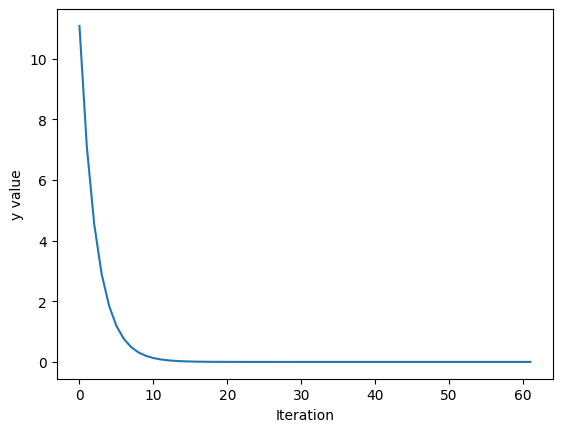

In [76]:
# plot y_values over time
plt.plot(y_values)
plt.xlabel("Iteration")
plt.ylabel("y value") 